<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_5/Laboratorio_5_PyTorch_Clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 5 Clasificación Binaria con PyTorch
## Detección de URLs Phishing hiUSIIL Dataset

**Curso:** SIS-420 Inteligencia Artificial  
**Dataset:** [PhiUSIIL Phishing URL Dataset (UCI)](https://archive.uci.edu/dataset/967/phiusiil+phishing+url+dataset)  
**Fuente original (Lab 5):** Regresión Logística con NumPy/SciPy  
**Este cuadernillo:** Misma tarea, resuelta con Red Neuronal en **PyTorch**

### Objetivo
Demostrar que la solución implementada con Regresión Logística en el Lab 5 se puede **mejorar y replicar** con una Red Neuronal profunda en PyTorch, aplicando:
- `nn.Module` para definir la arquitectura (cuadernillo 02)
- `Dataset` + `DataLoader` para manejo eficiente de datos (cuadernillo 03)
- Checkpoint del **mejor modelo** durante entrenamiento (cuadernillo 04)
- **Dropout** para evitar memorización
- **Early Stopping** guiado por el log cost de validación

### ⚠️ Regla del entrenamiento
 *"El modelo no debe memorizar. El log cost (curva de pérdida) es el diagnóstico:  
 si train loss baja a cero pero val loss sube → el entrenamiento está mal."*


In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


## Importaciones y Configuración del Entorno

In [6]:
# ── Core PyTorch ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ── Ciencia de datos ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from matplotlib import pyplot
%matplotlib inline
pyplot.rcParams['figure.facecolor'] = 'white'
pyplot.rcParams['grid.alpha'] = 0.3

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Google Drive ──────────────────────────────────────────────────────────────
from google.colab import drive

# ── Semillas para reproducibilidad ───────────────────────────────────────────
np.random.seed(42)
torch.manual_seed(42)

print('Importaciones completadas')

Importaciones completadas


In [7]:
# Detectar GPU — igual que en los cuadernillos del ingeniero
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"{'='*50}")
print(f'Dispositivo disponible: {device.upper()}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print('GPU NO disponible. El entrenamiento será más lento.')
print(f"{'='*50}")

Dispositivo disponible: CUDA
GPU: Tesla T4
Memoria GPU: 15.64 GB


## Carga y Preprocesamiento de Datos

Se mantiene **exactamente** el mismo preprocesamiento del Lab 5:  
descartar columnas de texto, separar X/y, split 80/20, normalización Z-score.  
La única diferencia es que al final convertimos a tensores PyTorch.

In [8]:
# ── 1.1 Carga del dataset ─────────────────────────────────────────────────────
ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(ruta)

print('Dimensiones del dataset (original):', df.shape)
print('Valores nulos:', df.isnull().sum().sum())
print()
print(df.head(5))

Dimensiones del dataset (original): (235795, 56)
Valores nulos: 0

     FILENAME                                 URL  URLLength  \
0  521848.txt    https://www.southbankmosaics.com         31   
1   31372.txt            https://www.uni-mainz.de         23   
2  597387.txt      https://www.voicefmradio.co.uk         29   
3  554095.txt         https://www.sfnmjournal.com         26   
4  151578.txt  https://www.rewildingargentina.org         33   

                       Domain  DomainLength  IsDomainIP  TLD  \
0    www.southbankmosaics.com            24           0  com   
1            www.uni-mainz.de            16           0   de   
2      www.voicefmradio.co.uk            22           0   uk   
3         www.sfnmjournal.com            19           0  com   
4  www.rewildingargentina.org            26           0  org   

   URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  Pay  \
0               100.0              1.000000           0.522907  ...    0   
1          

In [9]:
# ── 1.2 Limpieza — igual que Lab 5 ───────────────────────────────────────────
# Se descartan columnas no predictivas / de texto
df = df.drop(['FILENAME', 'URL', 'Domain', 'TLD', 'Title'], axis=1)

print('Dimensiones después de limpieza:', df.shape)
print('Columnas predictivas:', df.shape[1] - 1)   # sin 'label'
print()

# Distribución de clases
print('Distribución de clases:')
print(df['label'].value_counts())
print('  1 = LEGÍTIMA | 0 = PHISHING')

Dimensiones después de limpieza: (235795, 51)
Columnas predictivas: 50

Distribución de clases:
label
1    134850
0    100945
Name: count, dtype: int64
  1 = LEGÍTIMA | 0 = PHISHING


In [10]:
# ── 1.3 Separación X / y ─────────────────────────────────────────────────────
# Reorganizar columnas: label al final (igual que Lab 5)
cols = [c for c in df.columns if c != 'label'] + ['label']
df = df[cols]

data = df.values.astype(float)

X = data[:, :50]   # 50 características
y = data[:, 50]    # etiqueta binaria: 0 = phishing, 1 = legítima
m = y.size

print(f'Total de ejemplos (m): {m:,}')
print(f'Características    (n): {X.shape[1]}')

Total de ejemplos (m): 235,795
Características    (n): 50


In [11]:
# ── 1.4 División 80 / 20 — idéntica al Lab 5 ─────────────────────────────────
np.random.seed(42)
indices = np.random.permutation(m)

m_train = int(m * 0.8)
m_test  = m - m_train

X_train = X[indices[:m_train]]
y_train = y[indices[:m_train]]
X_test  = X[indices[m_train:]]
y_test  = y[indices[m_train:]]

print(f'Train: {m_train:,} ejemplos (80%)')
print(f'Test:  {m_test:,} ejemplos (20%)')

Train: 188,636 ejemplos (80%)
Test:  47,159 ejemplos (20%)


In [12]:
# ── 1.5 Normalización Z-score — SOLO con estadísticas de TRAIN ───────────────
#
# CRÍTICO: calcular mu y sigma ÚNICAMENTE del conjunto de entrenamiento.
# Aplicar la misma transformación al test. Si usáramos estadísticas del test
# estaríamos filtrando información → data leakage.
#
mu    = np.mean(X_train, axis=0)
sigma = np.std(X_train,  axis=0)
sigma[sigma == 0] = 1              # evitar división por cero

X_train_norm = (X_train - mu) / sigma
X_test_norm  = (X_test  - mu) / sigma   # mismos mu y sigma del train

print('✓ Normalización Z-score aplicada (sin data leakage)')
print(f'  Media de X_train normalizado:       {X_train_norm.mean():.6f}')
print(f'  Desv. estándar de X_train normalizado: {X_train_norm.std():.6f}')

✓ Normalización Z-score aplicada (sin data leakage)
  Media de X_train normalizado:       0.000000
  Desv. estándar de X_train normalizado: 1.000000


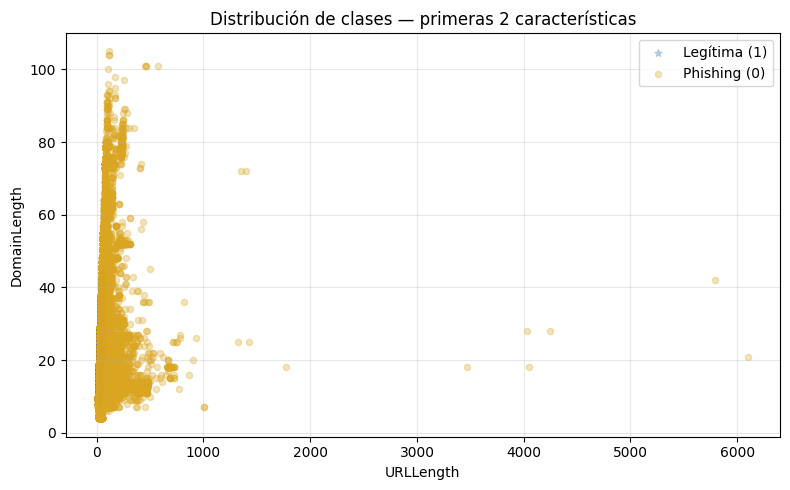

In [13]:
# ── 1.6 Visualización rápida — igual que Lab 5 ────────────────────────────────
pos = y_train == 1
neg = y_train == 0

pyplot.figure(figsize=(8, 5))
pyplot.scatter(X_train[pos, 0], X_train[pos, 1],
               c='steelblue', marker='*', s=30, alpha=0.3, label='Legítima (1)')
pyplot.scatter(X_train[neg, 0], X_train[neg, 1],
               c='goldenrod',  marker='o', s=20, alpha=0.3, label='Phishing (0)')
pyplot.xlabel('URLLength')
pyplot.ylabel('DomainLength')
pyplot.title('Distribución de clases — primeras 2 características')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## Dataset y DataLoader (cuadernillo 03)

En lugar de iterar sobre arrays NumPy manualmente (como en Lab 5),  
usamos las clases `Dataset` y `DataLoader` de PyTorch para:
- Empaquetar X e y juntos
- Iterar en **mini-batches** automáticamente
- Mezclar los datos en cada época (`shuffle=True`)

In [14]:
# ── 2.1 Clase Dataset personalizada (patrón del cuadernillo 03) ───────────────
class PhishingDataset(Dataset):
    """Dataset de URLs: legítimas vs phishing."""

    def __init__(self, X, y):
        # Convertimos a tensores float32 aquí dentro del Dataset
        # para encapsular la lógica de preparación
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().unsqueeze(1)  # (N,) → (N, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        return self.X[ix], self.y[ix]


# Instanciar datasets
train_dataset = PhishingDataset(X_train_norm, y_train)
test_dataset  = PhishingDataset(X_test_norm,  y_test)

print(f'✓ Datasets creados')
print(f'  Train: {len(train_dataset):,} ejemplos')
print(f'  Test:  {len(test_dataset):,} ejemplos')

# Verificar que devuelve shapes correctos
x_sample, y_sample = train_dataset[0]
print(f'  Muestra — X shape: {x_sample.shape}, y shape: {y_sample.shape}')

✓ Datasets creados
  Train: 188,636 ejemplos
  Test:  47,159 ejemplos
  Muestra — X shape: torch.Size([50]), y shape: torch.Size([1])


In [15]:
# ── 2.2 DataLoaders (patrón del cuadernillo 03) ───────────────────────────────
#
# batch_size = 512: procesa 512 URLs simultáneamente → eficiencia en GPU
# shuffle=True  en train: mezcla datos al inicio de cada época
# shuffle=False en test:  mantiene orden para comparar con etiquetas reales
#
BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'✓ DataLoaders creados')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Train batches: {len(train_loader)}')
print(f'  Test  batches: {len(test_loader)}')

✓ DataLoaders creados
  Batch size: 512
  Train batches: 369
  Test  batches: 93


## Arquitectura del Modelo (cuadernillo 02)

Red Neuronal con `nn.Module`, siguiendo el patrón del cuadernillo 02.

```
Input (50 características)
    ↓
Linear(50 → 128) + ReLU + Dropout(0.3)
    ↓
Linear(128 → 64) + ReLU + Dropout(0.3)
    ↓
Linear(64 → 32)  + ReLU + Dropout(0.2)
    ↓
Linear(32 → 1)   + Sigmoid  ← probabilidad de ser legítima
```

### ¿Por qué Dropout?
Dropout desactiva aleatoriamente un porcentaje de neuronas en cada paso  
de entrenamiento. Esto obliga al modelo a **no memorizar rutas específicas**  
y a aprender representaciones más robustas.

> Sin Dropout: train loss → 0, val loss → sube (memorización = **MAL**)  
> Con Dropout: ambas curvas bajan juntas (generalización = **BIEN**)

In [16]:
# ── 3.1 Definición del modelo — patrón nn.Module del cuadernillo 02 ───────────
class PhishingClassifier(nn.Module):
    """Red Neuronal para detectar URLs de phishing."""

    def __init__(self, input_size=50):
        super(PhishingClassifier, self).__init__()

        # Capas lineales
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

        # Activación
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()   # salida: probabilidad [0, 1]

        # Dropout — previene memorización
        self.dropout1 = nn.Dropout(p=0.3)
        self.dropout2 = nn.Dropout(p=0.3)
        self.dropout3 = nn.Dropout(p=0.2)

    def forward(self, x):
        x = self.dropout1(self.relu(self.fc1(x)))
        x = self.dropout2(self.relu(self.fc2(x)))
        x = self.dropout3(self.relu(self.fc3(x)))
        x = self.sigmoid(self.fc4(x))   # sin Dropout en la salida
        return x


# Crear instancia y mover a GPU/CPU
model = PhishingClassifier(input_size=50).to(device)

print(f'✓ Modelo creado y movido a {device.upper()}')
print()
print(model)

✓ Modelo creado y movido a CUDA

PhishingClassifier(
  (fc1): Linear(in_features=50, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout1): Dropout(p=0.3, inplace=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (dropout3): Dropout(p=0.2, inplace=False)
)


In [17]:
# ── 3.2 Función de pérdida y optimizador ─────────────────────────────────────
#
# BCELoss: Binary Cross Entropy — equivalente al log-loss del Lab 5
#   J = -1/m * Σ [ y·log(h) + (1-y)·log(1-h) ]
#
# Adam: ajusta la tasa de aprendizaje por parámetro dinámicamente.
#
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print('✓ Función de pérdida: BCELoss  (Binary Cross Entropy — igual que Lab 5)')
print('✓ Optimizador:        Adam     (lr=0.001)')

✓ Función de pérdida: BCELoss  (Binary Cross Entropy — igual que Lab 5)
✓ Optimizador:        Adam     (lr=0.001)


## Entrenamiento con Early Stopping

### El diagnóstico: el log cost

En cada época graficamos **dos curvas**:
- `Train Loss`: error sobre datos de entrenamiento
- `Val Loss`: error sobre datos que el modelo **nunca vio**

Si `train loss` baja pero `val loss` sube → el modelo está memorizando → **entrenamiento mal**.  
Si ambas bajan juntas y convergen → el modelo está generalizando → **entrenamiento bien**.

### Early Stopping
Detenemos el entrenamiento automáticamente cuando `val loss` no mejora  
por `PATIENCE` épocas consecutivas. Guardamos el **mejor modelo** (cuadernillo 04).

In [18]:
# ── 4.1 Parámetros de entrenamiento ──────────────────────────────────────────
NUM_EPOCHS   = 200    # máximo de épocas (early stopping puede cortar antes)
PATIENCE     = 15     # épocas sin mejora antes de detener
CHECKPOINT   = 'best_phishing_model.pth'

# Historial de pérdidas (para graficar el log cost)
train_losses = []
val_losses   = []

# Variables de Early Stopping
best_val_loss      = float('inf')
epochs_sin_mejora  = 0
best_epoch         = 0

print(f'Configuración de entrenamiento:')
print(f'  Épocas máximas:  {NUM_EPOCHS}')
print(f'  Patience:        {PATIENCE}')
print(f'  Checkpoint:      {CHECKPOINT}')
print()
print('Iniciando entrenamiento...')
print('='*65)

Configuración de entrenamiento:
  Épocas máximas:  200
  Patience:        15
  Checkpoint:      best_phishing_model.pth

Iniciando entrenamiento...


In [19]:
# ── 4.2 Bucle de entrenamiento — patrón del cuadernillo 02 ───────────────────
for epoch in range(1, NUM_EPOCHS + 1):

    # ─── ENTRENAMIENTO ────────────────────────────────────────────────────────
    model.train()   # activa Dropout (capas se comportan diferente en train/eval)
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        # Mover batch a GPU/CPU
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Forward pass
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)

        # Backward pass
        optimizer.zero_grad()   # limpiar gradientes acumulados
        loss.backward()         # calcular gradientes (autograd)
        optimizer.step()        # actualizar pesos: w = w - lr * grad

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ─── VALIDACIÓN ───────────────────────────────────────────────────────────
    model.eval()    # desactiva Dropout para evaluación
    val_loss = 0.0

    with torch.no_grad():   # no calcular gradientes → más rápido
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred  = model(X_batch)
            loss    = criterion(y_pred, y_batch)
            val_loss += loss.item()

    val_loss /= len(test_loader)

    # ─── REGISTRO ─────────────────────────────────────────────────────────────
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # ─── CHECKPOINT: guardar SOLO si val_loss mejoró (cuadernillo 04) ─────────
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_epoch        = epoch
        epochs_sin_mejora = 0
        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss':             val_loss,
            'train_loss':           train_loss,
            'normalization_params': {'mu': mu, 'sigma': sigma}
        }, CHECKPOINT)
        mejora_tag = '  ← mejor modelo guardado ✓'
    else:
        epochs_sin_mejora += 1
        mejora_tag = f'  (sin mejora: {epochs_sin_mejora}/{PATIENCE})'

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:>3}/{NUM_EPOCHS} | '
              f'Train Loss: {train_loss:.4f} | '
              f'Val Loss: {val_loss:.4f}{mejora_tag}')

    # ─── EARLY STOPPING ───────────────────────────────────────────────────────
    if epochs_sin_mejora >= PATIENCE:
        print(f'\n⚡ Early stopping en época {epoch}')
        print(f'   Mejor val_loss: {best_val_loss:.4f} (época {best_epoch})')
        break

print(f'\n✓ Entrenamiento completado')
print(f'  Mejor época: {best_epoch}  |  Mejor val_loss: {best_val_loss:.4f}')

Época   1/200 | Train Loss: 0.0507 | Val Loss: 0.0013  ← mejor modelo guardado ✓
Época  10/200 | Train Loss: 0.0002 | Val Loss: 0.0005  (sin mejora: 1/15)
Época  20/200 | Train Loss: 0.0001 | Val Loss: 0.0005  (sin mejora: 11/15)
Época  30/200 | Train Loss: 0.0001 | Val Loss: 0.0003  (sin mejora: 9/15)
Época  40/200 | Train Loss: 0.0001 | Val Loss: 0.0004  (sin mejora: 2/15)
Época  50/200 | Train Loss: 0.0000 | Val Loss: 0.0006  (sin mejora: 12/15)

⚡ Early stopping en época 53
   Mejor val_loss: 0.0002 (época 38)

✓ Entrenamiento completado
  Mejor época: 38  |  Mejor val_loss: 0.0002


In [22]:
# ── 4.3 Cargar el MEJOR modelo (no el último) — cuadernillo 04 ───────────────
#
# El modelo de la última época NO es necesariamente el mejor.
# Cargamos el checkpoint guardado en la época con menor val_loss.
#
checkpoint = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'✓ Mejor modelo cargado desde checkpoint')
print(f'  Época guardada: {checkpoint["epoch"]}')
print(f'  Train Loss:     {checkpoint["train_loss"]:.4f}')
print(f'  Val   Loss:     {checkpoint["val_loss"]:.4f}')

✓ Mejor modelo cargado desde checkpoint
  Época guardada: 38
  Train Loss:     0.0001
  Val   Loss:     0.0002


## Análisis del Log Cost

Este gráfico es el **diagnóstico principal** del entrenamiento.  
Si el modelo aprendió correctamente, ambas curvas deben:
1. Bajar juntas desde el inicio
2. Estabilizarse en valores similares
3. **NO** mostrar brecha creciente entre train y val

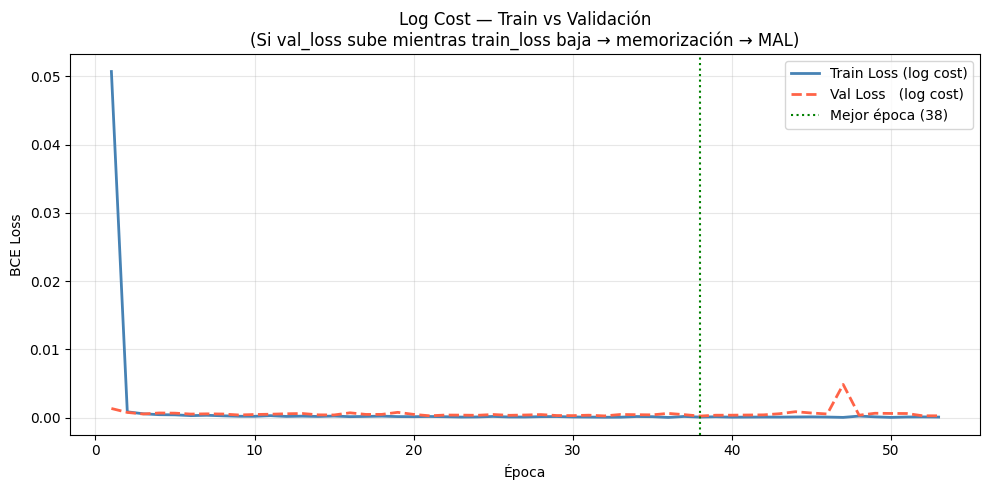


Diagnóstico del entrenamiento:
  Train loss final: 0.0001
  Val   loss final: 0.0003
  Brecha (|val-train|): 0.0002
  ✓ Brecha pequeña — el modelo generalizó correctamente


In [23]:
# ── 5.1 Gráfica del log cost — diagnóstico de memorización ───────────────────
epocas = range(1, len(train_losses) + 1)

pyplot.figure(figsize=(10, 5))
pyplot.plot(epocas, train_losses, label='Train Loss (log cost)', linewidth=2, color='steelblue')
pyplot.plot(epocas, val_losses,   label='Val Loss   (log cost)', linewidth=2,
            color='tomato', linestyle='--')

# Marcar la mejor época
pyplot.axvline(x=best_epoch, color='green', linestyle=':', linewidth=1.5,
               label=f'Mejor época ({best_epoch})')

pyplot.xlabel('Época')
pyplot.ylabel('BCE Loss')
pyplot.title('Log Cost — Train vs Validación\n'
             '(Si val_loss sube mientras train_loss baja → memorización → MAL)')
pyplot.legend()
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

# ── Diagnóstico automático ────────────────────────────────────────────────────
brecha_final = abs(val_losses[-1] - train_losses[-1])
print(f'\nDiagnóstico del entrenamiento:')
print(f'  Train loss final: {train_losses[-1]:.4f}')
print(f'  Val   loss final: {val_losses[-1]:.4f}')
print(f'  Brecha (|val-train|): {brecha_final:.4f}')
if brecha_final < 0.05:
    print('  ✓ Brecha pequeña — el modelo generalizó correctamente')
elif brecha_final < 0.15:
    print('    Brecha moderada — revisar Dropout o reducir épocas')
else:
    print('  ✗ Brecha grande — el modelo memorizó → entrenamiento MAL')

## Evaluación del Modelo

Se evalúa sobre el 20% de datos que el modelo **nunca vio**,  
comparando con las métricas del Lab 5 (regresión logística clásica).

In [24]:
# ── 6.1 Predicciones sobre el conjunto de prueba ─────────────────────────────
model.eval()
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        probs   = model(X_batch).cpu().numpy()
        preds   = (probs >= 0.5).astype(int)

        all_probs.extend(probs.flatten())
        all_preds.extend(preds.flatten())
        all_labels.extend(y_batch.numpy().flatten())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('✓ Predicciones generadas')

✓ Predicciones generadas


In [25]:
# ── 6.2 Métricas ─────────────────────────────────────────────────────────────
accuracy  = accuracy_score(all_labels,  all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels,    all_preds)
f1        = f1_score(all_labels,        all_preds)

print(f"{'='*50}")
print(f'EVALUACIÓN — MODELO PYTORCH (conjunto de prueba 20%)')
print(f"{'='*50}")
print(f'Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f} %)')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')
print(f"{'='*50}")
print()
print('Referencia Lab 5 (Regresión Logística clásica): 99.99 %')
print(f'Este modelo (Red Neuronal PyTorch):             {accuracy*100:.2f} %')

EVALUACIÓN — MODELO PYTORCH (conjunto de prueba 20%)
Accuracy:  0.9999  (99.99 %)
Precision: 0.9999
Recall:    1.0000
F1-Score:  0.9999

Referencia Lab 5 (Regresión Logística clásica): 99.99 %
Este modelo (Red Neuronal PyTorch):             99.99 %


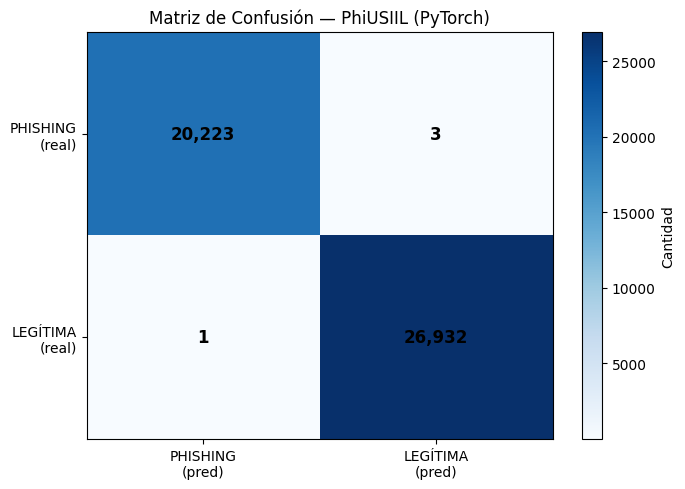


              precision    recall  f1-score   support

    PHISHING       1.00      1.00      1.00     20226
    LEGÍTIMA       1.00      1.00      1.00     26933

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



In [26]:
# ── 6.3 Matriz de confusión ───────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

pyplot.figure(figsize=(7, 5))
pyplot.imshow(cm, cmap='Blues', aspect='auto')
pyplot.colorbar(label='Cantidad')

for i in range(2):
    for j in range(2):
        pyplot.text(j, i, f'{cm[i,j]:,}',
                   ha='center', va='center',
                   color='black', fontweight='bold', fontsize=12)

pyplot.xticks([0, 1], ['PHISHING\n(pred)', 'LEGÍTIMA\n(pred)'])
pyplot.yticks([0, 1], ['PHISHING\n(real)', 'LEGÍTIMA\n(real)'])
pyplot.title('Matriz de Confusión — PhiUSIIL (PyTorch)')
pyplot.tight_layout()
pyplot.show()

print()
print(classification_report(all_labels, all_preds,
                             target_names=['PHISHING', 'LEGÍTIMA']))

In [27]:
# ── 6.4 Comparativa: 20 predicciones individuales ────────────────────────────
# (igual que Lab 5 para facilitar comparación visual)
print(f"{'Ej':>5s}{'Real':>10s}{'Predicho':>12s}{'Probabilidad':>14s}{'Correcto':>10s}")
print('-' * 54)

for i in range(20):
    real_label = 'LEGÍTIMA' if all_labels[i] == 1 else 'PHISHING'
    pred_label = 'LEGÍTIMA' if all_preds[i]  == 1 else 'PHISHING'
    correcto   = '✓' if all_preds[i] == all_labels[i] else '✗'
    print(f"{i+1:>5d}{real_label:>10s}{pred_label:>12s}{all_probs[i]:>14.4f}{correcto:>10s}")

print()
precision_20 = np.mean(all_preds[:20] == all_labels[:20]) * 100
print(f'Precisión sobre primeras 20 predicciones: {precision_20:.2f} %')

   Ej      Real    Predicho  Probabilidad  Correcto
------------------------------------------------------
    1  PHISHING    PHISHING        0.0000         ✓
    2  PHISHING    PHISHING        0.0000         ✓
    3  PHISHING    PHISHING        0.0000         ✓
    4  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
    5  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
    6  PHISHING    PHISHING        0.0000         ✓
    7  PHISHING    PHISHING        0.0000         ✓
    8  PHISHING    PHISHING        0.0000         ✓
    9  PHISHING    PHISHING        0.0000         ✓
   10  PHISHING    PHISHING        0.0000         ✓
   11  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
   12  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
   13  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
   14  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
   15  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
   16  LEGÍTIMA    LEGÍTIMA        1.0000         ✓
   17  PHISHING    PHISHING        0.0000         ✓
   18  LE

##  Carga y Uso del Modelo Guardado (cuadernillo 04)

Demostración de que el checkpoint es completo y funcional:  
se carga en un modelo nuevo y se hacen predicciones sin reentrenar.

In [30]:
# ── 7.1 Función para cargar el modelo guardado ────────────────────────────────
def cargar_modelo_phishing(checkpoint_path, device):
    """Carga el modelo de detección de phishing desde checkpoint."""
    ckpt  = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model = PhishingClassifier(input_size=50).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    norm_params = ckpt['normalization_params']
    print(f'✓ Modelo cargado  (época {ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.4f})')
    return model, norm_params


def predecir_url(X_raw, model, norm_params, device, threshold=0.5):
    """Predice si URLs son legítimas (1) o phishing (0)."""
    # Aplicar normalización con parámetros guardados en el checkpoint
    X_norm = (X_raw - norm_params['mu']) / norm_params['sigma']
    X_t    = torch.from_numpy(X_norm).float().to(device)

    with torch.no_grad():
        probs = model(X_t).cpu().numpy().flatten()

    preds = (probs >= threshold).astype(int)
    return probs, preds


print('✓ Funciones de deployment definidas')

✓ Funciones de deployment definidas


In [31]:
# ── 7.2 Usar el modelo guardado en nuevos datos ───────────────────────────────
modelo_cargado, norm_params_cargados = cargar_modelo_phishing(CHECKPOINT, device)

# 5 URLs aleatorias del conjunto de prueba
idx_muestra = np.random.choice(len(X_test), size=5, replace=False)
X_muestra   = X_test[idx_muestra]   # datos SIN normalizar (la función lo hace internamente)
y_muestra   = y_test[idx_muestra]

probs_muestra, preds_muestra = predecir_url(X_muestra, modelo_cargado,
                                             norm_params_cargados, device)

print(f"\n{'='*60}")
print('PREDICCIONES NUEVAS (modelo cargado desde checkpoint)')
print(f"{'='*60}")

for i in range(5):
    real = 'LEGÍTIMA' if y_muestra[i] == 1 else 'PHISHING'
    pred = 'LEGÍTIMA' if preds_muestra[i] == 1 else 'PHISHING'
    icono = '✓' if preds_muestra[i] == y_muestra[i] else '✗'
    print(f'\n  Ejemplo {i+1}:')
    print(f'    Real:        {real}')
    print(f'    Predicho:    {pred}  (prob={probs_muestra[i]:.4f})')
    print(f'    Correcto:    {icono}')

✓ Modelo cargado  (época 38, val_loss=0.0002)

PREDICCIONES NUEVAS (modelo cargado desde checkpoint)

  Ejemplo 1:
    Real:        LEGÍTIMA
    Predicho:    LEGÍTIMA  (prob=1.0000)
    Correcto:    ✓

  Ejemplo 2:
    Real:        LEGÍTIMA
    Predicho:    LEGÍTIMA  (prob=1.0000)
    Correcto:    ✓

  Ejemplo 3:
    Real:        PHISHING
    Predicho:    PHISHING  (prob=0.0000)
    Correcto:    ✓

  Ejemplo 4:
    Real:        PHISHING
    Predicho:    PHISHING  (prob=0.0000)
    Correcto:    ✓

  Ejemplo 5:
    Real:        PHISHING
    Predicho:    PHISHING  (prob=0.0000)
    Correcto:    ✓


In [32]:
# ── Resumen final ─────────────────────────────────────────────────────────────
print('='*60)
print('RESUMEN FINAL')
print('='*60)
print(f'Dataset:          PhiUSIIL Phishing URL ({m:,} URLs)')
print(f'Train:            {m_train:,} (80%)')
print(f'Test:             {m_test:,}  (20%)')
print(f'Arquitectura:     50 → 128 → 64 → 32 → 1')
print(f'Épocas totales:   {len(train_losses)}')
print(f'Mejor época:      {best_epoch}')
print(f'Train Loss final: {train_losses[best_epoch-1]:.4f}')
print(f'Val   Loss final: {val_losses[best_epoch-1]:.4f}')
print(f'Accuracy:         {accuracy*100:.2f} %')
print(f'F1-Score:         {f1:.4f}')
print(f'Checkpoint:       {CHECKPOINT}')
print('='*60)

RESUMEN FINAL
Dataset:          PhiUSIIL Phishing URL (235,795 URLs)
Train:            188,636 (80%)
Test:             47,159  (20%)
Arquitectura:     50 → 128 → 64 → 32 → 1
Épocas totales:   53
Mejor época:      38
Train Loss final: 0.0001
Val   Loss final: 0.0002
Accuracy:         99.99 %
F1-Score:         0.9999
Checkpoint:       best_phishing_model.pth
